In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42  # reused everywhere so results are reproducible

print("Libraries imported successfully.")
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("joblib       :", joblib.__version__)

Libraries imported successfully.
pandas       : 2.2.3
numpy        : 2.1.3
scikit-learn : 1.6.1
joblib       : 1.6.0


In [3]:
from google.colab import files
import os

print("Please choose your Phishing URL CSV file...")
uploaded = files.upload()   # opens a file-picker dialog

if len(uploaded) == 0:
    raise FileNotFoundError("No file was uploaded. Re-run this cell and select your CSV file.")

csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]

if len(csv_files) == 0:
    raise ValueError(f"No .csv file found. You uploaded: {list(uploaded.keys())}")

if len(csv_files) > 1:
    print("Warning: multiple CSV files uploaded. Using the first one:", csv_files[0])

DATASET_FILENAME = csv_files[0]   # exact name as stored in Colab

print("\nUploaded files   :", list(uploaded.keys()))
print("Exact filename   :", DATASET_FILENAME)
print("File size (KB)   :", round(os.path.getsize(DATASET_FILENAME) / 1024, 2))

Please choose your Phishing URL CSV file...


Saving phishing_url_dataset.csv to phishing_url_dataset.csv

Uploaded files   : ['phishing_url_dataset.csv']
Exact filename   : phishing_url_dataset.csv
File size (KB)   : 74.17


In [4]:
# Try the most common encoding first, then fall back to latin-1
try:
    df = pd.read_csv(DATASET_FILENAME)
except UnicodeDecodeError:
    df = pd.read_csv(DATASET_FILENAME, encoding="latin-1")

# Remove accidental spaces around column names (e.g. " target" -> "target")
original_columns = list(df.columns)
df.columns = df.columns.str.strip()
if original_columns != list(df.columns):
    print("Note: extra spaces were removed from some column names.\n")

print("Dataset loaded successfully from:", DATASET_FILENAME)
print("Shape (rows, columns):", df.shape)

expected_features = [
    "url_length", "valid_url", "at_symbol", "sensitive_words_count",
    "path_length", "isHttps", "nb_dots", "nb_hyphens", "nb_and",
    "nb_or", "nb_www", "nb_com", "nb_underscore"
]

present = [c for c in expected_features if c in df.columns]
missing = [c for c in expected_features if c not in df.columns]

print("\nExpected feature columns FOUND   :", present)
print("Expected feature columns MISSING :", missing)

# ---- Find the target column ----
target_candidates = [c for c in df.columns if c.lower() == "target"]
if len(target_candidates) == 0:
    print("\nNo column named 'target' was found.")
    print("Actual columns are:", list(df.columns))
    print("Tell me which one is the label and I will adapt the code.")
    TARGET_COL = None
else:
    TARGET_COL = target_candidates[0]
    print("\nTarget column detected:", TARGET_COL)

# Columns that are in the file but not in my expected list
extra_columns = [c for c in df.columns if c not in expected_features and c != TARGET_COL]
print("Extra columns in your file (not in my list):", extra_columns)

Dataset loaded successfully from: phishing_url_dataset.csv
Shape (rows, columns): (2488, 14)

Expected feature columns FOUND   : ['url_length', 'valid_url', 'at_symbol', 'sensitive_words_count', 'path_length', 'isHttps', 'nb_dots', 'nb_hyphens', 'nb_and', 'nb_or', 'nb_www', 'nb_com', 'nb_underscore']
Expected feature columns MISSING : []

Target column detected: target
Extra columns in your file (not in my list): []


In [5]:
print("=" * 60)
print("1. EXACT FILENAME")
print("=" * 60)
print(DATASET_FILENAME)

print("\n" + "=" * 60)
print("2. FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("3. SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("4. COLUMN NAMES")
print("=" * 60)
print(list(df.columns))

print("\n" + "=" * 60)
print("5. DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("6. DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("7. STATISTICAL SUMMARY")
print("=" * 60)
display(df.describe().T)

print("\n" + "=" * 60)
print("8. MISSING VALUES")
print("=" * 60)
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})
display(missing_report)
print("Total missing cells:", int(df.isnull().sum().sum()))

print("\n" + "=" * 60)
print("9. DUPLICATE ROWS")
print("=" * 60)
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count:,} ({dup_count / len(df) * 100:.2f}% of the data)")
if dup_count > 0:
    print("\nExample duplicated rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6))

print("\n" + "=" * 60)
print("10. TARGET DISTRIBUTION")
print("=" * 60)
if TARGET_COL is None:
    print("Target column not identified. Fix this in Cell 3 first.")
else:
    counts = df[TARGET_COL].value_counts(dropna=False).sort_index()
    percents = (df[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
    target_summary = pd.DataFrame({"count": counts, "percent": percents})
    display(target_summary)

    unexpected = set(df[TARGET_COL].dropna().unique()) - {0, 1}
    if unexpected:
        print("WARNING: target contains values other than 0 and 1:", unexpected)
    else:
        print("Target contains only 0 and 1, as expected.")

    ratio = counts.max() / counts.min()
    print(f"Majority:minority ratio = {ratio:.2f}:1",
          "(fairly balanced)" if ratio < 1.5 else "(imbalanced, we will handle this)")

1. EXACT FILENAME
phishing_url_dataset.csv

2. FIRST 5 ROWS


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,0,52,0,5,0,0,0,0,1,0,0



3. SHAPE
Rows: 2,488   Columns: 14

4. COLUMN NAMES
['url_length', 'valid_url', 'at_symbol', 'sensitive_words_count', 'path_length', 'isHttps', 'nb_dots', 'nb_hyphens', 'nb_and', 'nb_or', 'nb_www', 'nb_com', 'nb_underscore', 'target']

5. DATA TYPES
url_length               int64
valid_url                int64
at_symbol                int64
sensitive_words_count    int64
path_length              int64
isHttps                  int64
nb_dots                  int64
nb_hyphens               int64
nb_and                   int64
nb_or                    int64
nb_www                   int64
nb_com                   int64
nb_underscore            int64
target                   int64
dtype: object

6. DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2488 entries, 0 to 2487
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   url_length             2488 non-null   int64
 1   valid_url             

,count,mean,std,min,25%,50%,75%,max
url_length,2488.0,57.925241,20.186924,13.0,38.0,73.0,73.0,96.0
valid_url,2488.0,0.280145,0.449160,0.0,0.0,0.0,1.0,1.0
at_symbol,2488.0,0.008441,0.244623,0.0,0.0,0.0,0.0,9.0
sensitive_words_count,2488.0,0.232315,0.446459,0.0,0.0,0.0,0.0,3.0
path_length,2488.0,16.213424,18.857855,0.0,0.0,4.0,27.0,85.0
isHttps,2488.0,0.427653,0.494838,0.0,0.0,0.0,1.0,1.0
nb_dots,2488.0,4.709003,2.424851,0.0,2.0,5.0,6.0,13.0
nb_hyphens,2488.0,0.593650,1.251646,0.0,0.0,0.0,1.0,10.0
nb_and,2488.0,0.015273,0.125898,0.0,0.0,0.0,0.0,2.0
nb_or,2488.0,0.179260,0.429159,0.0,0.0,0.0,0.0,3.0



8. MISSING VALUES


...

Total missing cells: 0

9. DUPLICATE ROWS
Duplicate rows: 1,134 (45.58% of the data)

Example duplicated rows:


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
119,16,0,0,0,0,0,1,0,0,0,0,0,0,0
574,16,0,0,0,0,0,1,0,0,0,0,0,0,0
674,16,0,0,0,0,0,1,0,0,0,0,0,0,0
419,17,0,0,0,0,0,1,0,0,0,0,0,0,0
575,17,0,0,0,0,0,1,0,0,0,0,0,0,0
925,17,0,0,0,0,0,1,0,0,0,0,0,0,0



10. TARGET DISTRIBUTION


,count,percent
target,,
0,1313,52.77
1,1175,47.23


Target contains only 0 and 1, as expected.
Majority:minority ratio = 1.12:1 (fairly balanced)


In [6]:
if "df_raw" not in globals():
    df_raw = df.copy()
df = df_raw.copy()

feature_cols = [c for c in df.columns if c != TARGET_COL]
print("Original shape:", df.shape)

# ---------- Step 1: Missing values ----------
total_missing = int(df.isnull().sum().sum())
print("\n[1] Missing values:", total_missing)
if total_missing > 0:
    df = df.dropna(subset=[TARGET_COL])
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    print("    Rows with a missing target were dropped; missing features filled with the median.")
else:
    print("    None found, nothing to fix.")

# ---------- Step 2: Invalid / inconsistent values ----------
print("\n[2] Invalid / inconsistent value checks")
binary_cols = [c for c in ["valid_url", "isHttps"] if c in df.columns]

negatives = (df[feature_cols] < 0).sum()
print("    Columns with negative values       :", negatives[negatives > 0].to_dict() or "none")
for col in binary_cols:
    print(f"    {col:<35}: values other than 0/1 -> {int((~df[col].isin([0, 1])).sum())}")
print("    target values other than 0/1       :", int((~df[TARGET_COL].isin([0, 1])).sum()))

invalid_mask = (df[feature_cols] < 0).any(axis=1) | (~df[TARGET_COL].isin([0, 1]))
for col in binary_cols:
    invalid_mask |= ~df[col].isin([0, 1])

if {"path_length", "url_length"}.issubset(df.columns):
    longer_path = df["path_length"] > df["url_length"]
    print("    path_length > url_length (impossible):", int(longer_path.sum()))
    invalid_mask |= longer_path

print("    Total invalid rows removed         :", int(invalid_mask.sum()))
df = df[~invalid_mask]

print("\n    at_symbol is a COUNT, not a 0/1 flag. Its value counts:")
display(df["at_symbol"].value_counts().sort_index().to_frame("rows"))

# ---------- Step 3: Duplicates ----------
rows_before = len(df)
n_duplicates = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print(f"\n[3] Duplicate rows removed: {n_duplicates:,} ({rows_before:,} -> {len(df):,} rows)")

# Same feature values but DIFFERENT labels = contradictory rows
labels_per_pattern = df.groupby(feature_cols)[TARGET_COL].nunique()
n_conflicts = int((labels_per_pattern > 1).sum())
print(f"    Feature patterns that appear with BOTH labels: {n_conflicts}")
print("    (Kept on purpose: they are real overlap between classes, not errors.)")

# ---------- Step 4: Numerical vs categorical features ----------
numerical_cols = df[feature_cols].select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numerical_cols]
print("\n[4] Numerical features  :", len(numerical_cols))
print("    Categorical features:", categorical_cols if categorical_cols else "none -> no encoding needed")

# ---------- Summary ----------
print("\n" + "=" * 50)
print("CLEANING SUMMARY")
print("=" * 50)
print("Raw shape    :", df_raw.shape)
print("Cleaned shape:", df.shape)
summary = pd.DataFrame({
    "count": df[TARGET_COL].value_counts().sort_index(),
    "percent": (df[TARGET_COL].value_counts(normalize=True).sort_index() * 100).round(2)
})
summary.index = summary.index.map({0: "0 = Phishing", 1: "1 = Legitimate"})
display(summary)

Original shape: (2488, 14)

[1] Missing values: 0
    None found, nothing to fix.

[2] Invalid / inconsistent value checks
    Columns with negative values       : none
    valid_url                          : values other than 0/1 -> 0
    isHttps                            : values other than 0/1 -> 0
    target values other than 0/1       : 0
    path_length > url_length (impossible): 0
    Total invalid rows removed         : 0

    at_symbol is a COUNT, not a 0/1 flag. Its value counts:


,rows
at_symbol,
0,2482
1,4
8,1
9,1



[3] Duplicate rows removed: 1,134 (2,488 -> 1,354 rows)
    Feature patterns that appear with BOTH labels: 41
    (Kept on purpose: they are real overlap between classes, not errors.)

[4] Numerical features  : 13
    Categorical features: none -> no encoding needed

CLEANING SUMMARY
Raw shape    : (2488, 14)
Cleaned shape: (1354, 14)


,count,percent
target,,
0 = Phishing,905,66.84
1 = Legitimate,449,33.16


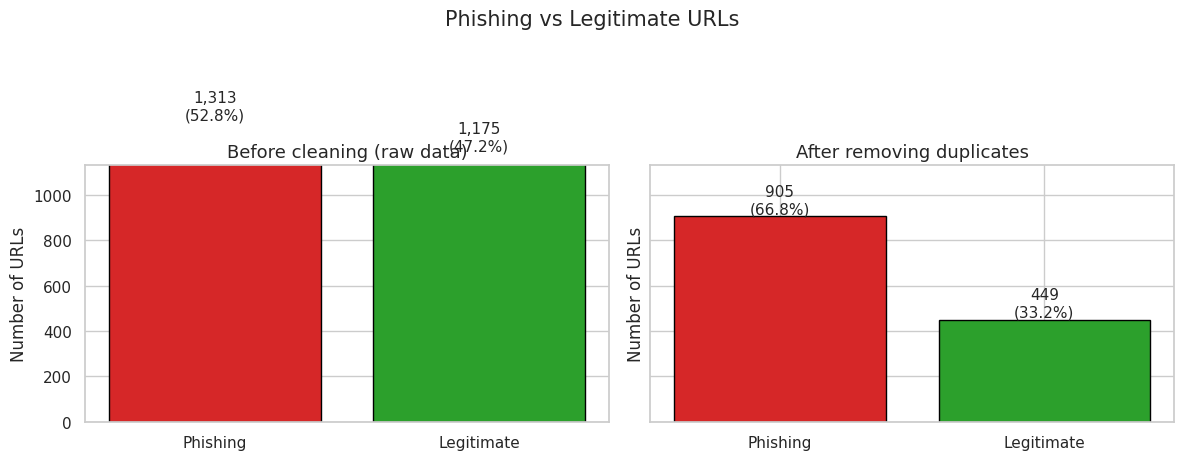

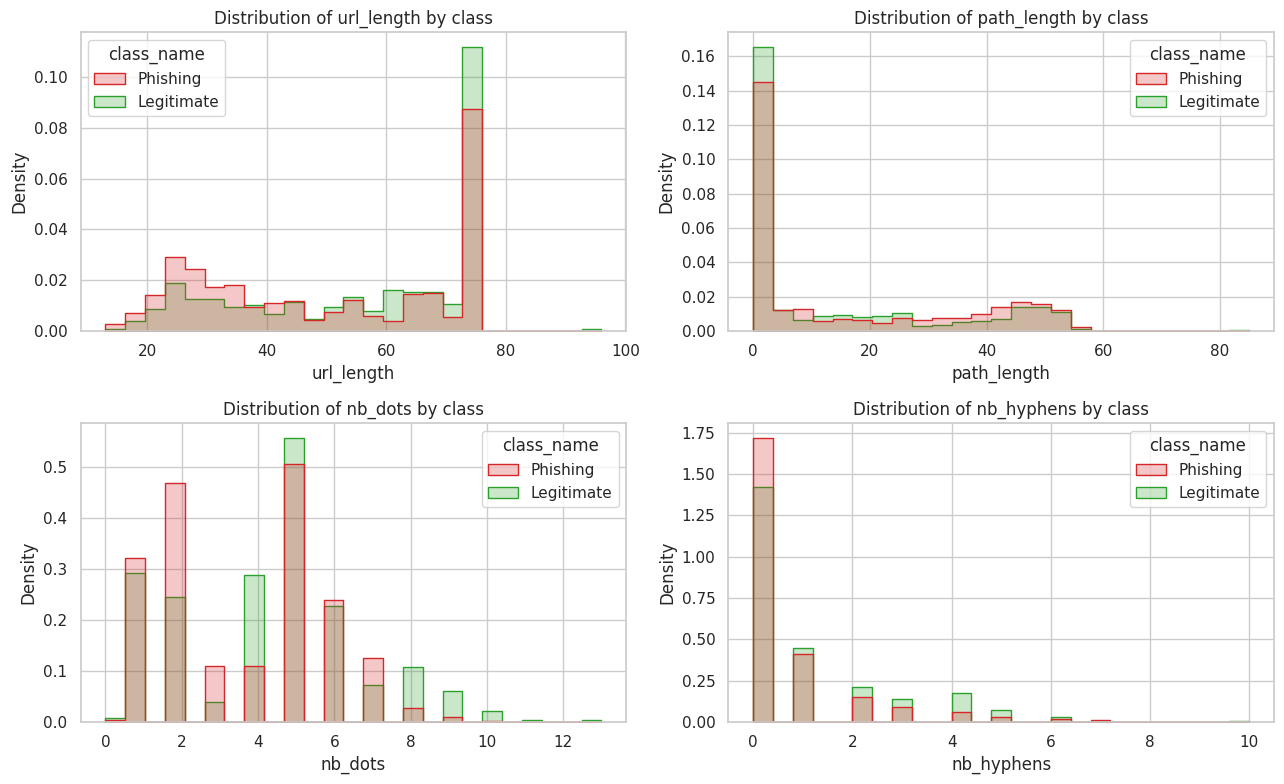

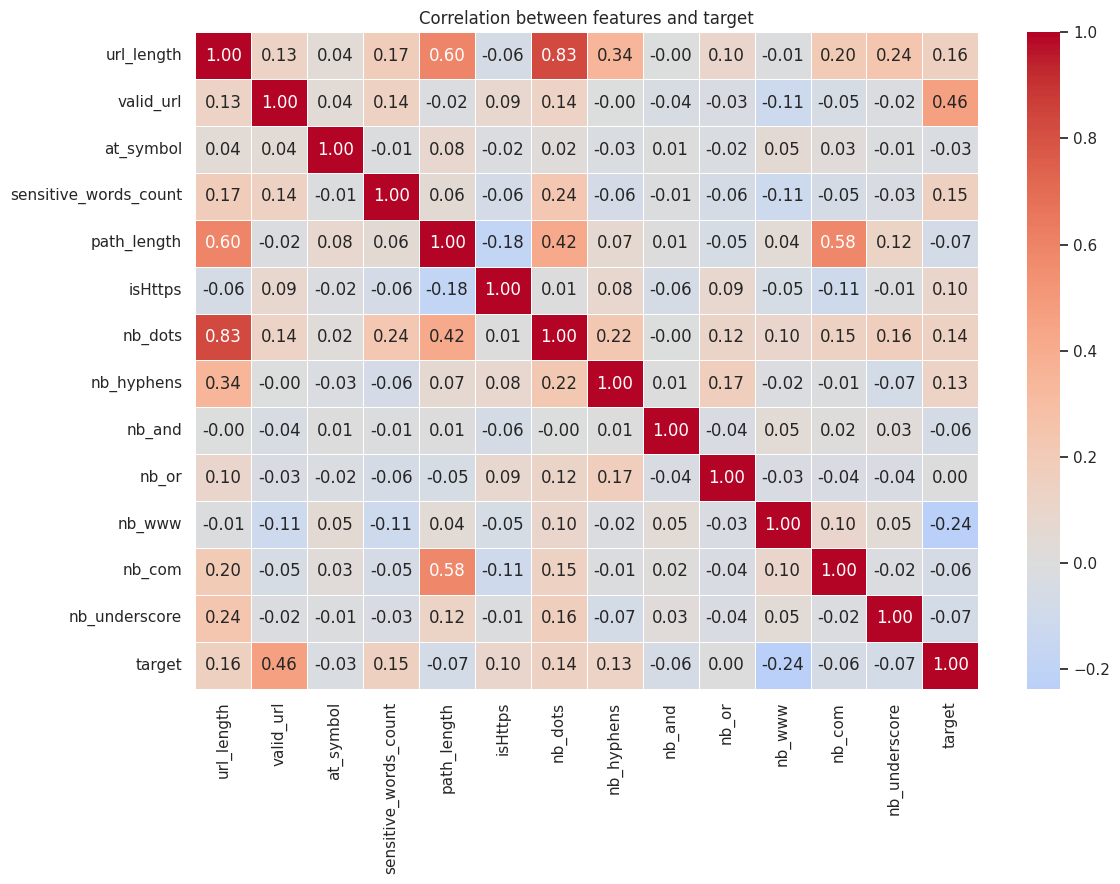

Correlation of each feature with target (sorted):


,correlation_with_target
nb_www,-0.237
nb_underscore,-0.072
path_length,-0.070
nb_and,-0.061
nb_com,-0.057
at_symbol,-0.028
nb_or,0.001
isHttps,0.099
nb_hyphens,0.133
nb_dots,0.137



Average feature value per class:


target,Phishing,Legitimate
url_length,49.568,56.283
valid_url,0.014,0.332
at_symbol,0.022,0.002
sensitive_words_count,0.107,0.238
path_length,16.317,13.457
isHttps,0.246,0.341
nb_dots,3.745,4.374
nb_hyphens,0.644,1.040
nb_and,0.032,0.011
nb_or,0.262,0.263


In [7]:
label_names = {0: "Phishing", 1: "Legitimate"}
colors = {"Phishing": "#d62728", "Legitimate": "#2ca02c"}
order = ["Phishing", "Legitimate"]

# ---------- Chart 1: Phishing vs Legitimate (before vs after cleaning) ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, data, title in zip(axes, [df_raw, df], ["Before cleaning (raw data)", "After removing duplicates"]):
    counts = data[TARGET_COL].map(label_names).value_counts().reindex(order)
    ax.bar(order, counts.values, color=[colors[k] for k in order], edgecolor="black")
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.015, f"{v:,}\n({v / counts.sum() * 100:.1f}%)", ha="center", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Number of URLs")
    ax.set_ylim(0, counts.max() * 1.25)
plt.suptitle("Phishing vs Legitimate URLs", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ---------- Chart 2: How key features differ between the two classes ----------
df_plot = df.copy()
df_plot["class_name"] = df_plot[TARGET_COL].map(label_names)

key_features = [c for c in ["url_length", "path_length", "nb_dots", "nb_hyphens"] if c in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), key_features):
    sns.histplot(data=df_plot, x=col, hue="class_name", hue_order=order, palette=colors,
                 bins=25, element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Distribution of {col} by class")
plt.tight_layout()
plt.show()

# ---------- Chart 3: Correlation heatmap ----------
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation between features and target")
plt.tight_layout()
plt.show()

print("Correlation of each feature with target (sorted):")
display(df.corr()[TARGET_COL].drop(TARGET_COL).sort_values().to_frame("correlation_with_target").round(3))

# ---------- Table: average feature value per class ----------
print("\nAverage feature value per class:")
display(df.groupby(df[TARGET_COL].map(label_names))[feature_cols].mean().T.round(3)[order])

In [8]:
# ---------- Step 1: Verify which expected features really exist ----------
expected_features = [
    "url_length", "valid_url", "at_symbol", "sensitive_words_count",
    "path_length", "isHttps", "nb_dots", "nb_hyphens", "nb_and",
    "nb_or", "nb_www", "nb_com", "nb_underscore"
]

FEATURES = [c for c in expected_features if c in df.columns]
not_found = [c for c in expected_features if c not in df.columns]

print("Features that will be used:", len(FEATURES))
print("Expected but NOT in dataset:", not_found if not_found else "none")
assert TARGET_COL not in FEATURES, "Target column must never be used as a feature!"

# ---------- Step 2: Why each feature can help ----------
why = {
    "url_length":            "Phishing URLs are often long or oddly sized to hide the real domain.",
    "valid_url":             "Indicates whether the URL passed a validity check; malformed URLs are suspicious.",
    "at_symbol":             "Everything before '@' is ignored by browsers, so attackers use it to disguise the true host.",
    "sensitive_words_count": "Words like 'login', 'secure', 'account' are used to look trustworthy.",
    "path_length":           "Long paths can bury deceptive text or tracking tokens.",
    "isHttps":               "Whether the URL uses HTTPS; many phishing sites imitate secure sites.",
    "nb_dots":               "Many dots usually mean many subdomains (e.g. paypal.com.evil.site).",
    "nb_hyphens":            "Hyphens are common in look-alike domains (e.g. secure-bank-login).",
    "nb_and":                "Count of '&' (query-string parameters), which can carry redirects or tracking data.",
    "nb_or":                 "Count of 'or' in the URL (check your dataset page for the exact definition).",
    "nb_www":                "Count of 'www'; misplaced or repeated 'www' can signal fake hosts.",
    "nb_com":                "Count of 'com'; '.com' repeated inside a URL can imitate a trusted domain.",
    "nb_underscore":         "Underscores are rare in real hostnames and common in auto-generated URLs.",
}
feature_info = pd.DataFrame({
    "feature": FEATURES,
    "why_it_may_help": [why[f] for f in FEATURES],
    "corr_with_target": [round(df[f].corr(df[TARGET_COL]), 3) for f in FEATURES],
})
display(feature_info.sort_values("corr_with_target", key=abs, ascending=False).reset_index(drop=True))

# ---------- Step 3: Quality checks ----------
constant = [f for f in FEATURES if df[f].nunique() <= 1]
print("\nConstant (useless) features:", constant if constant else "none")

corr_matrix = df[FEATURES].corr().abs()
high_pairs = [(a, b, round(corr_matrix.loc[a, b], 2))
              for i, a in enumerate(FEATURES) for b in FEATURES[i + 1:]
              if corr_matrix.loc[a, b] > 0.85]
print("Feature pairs with |correlation| > 0.85:", high_pairs if high_pairs else "none")

# ---------- Step 4: Build X and y ----------
X = df[FEATURES].copy()
y = df[TARGET_COL].copy()

print("\nX shape:", X.shape, "| y shape:", y.shape)
print("Target column in X?", TARGET_COL in X.columns)
print("Feature order (must be kept identical in Streamlit):")
print(FEATURES)

Features that will be used: 13
Expected but NOT in dataset: none


,feature,why_it_may_help,corr_with_target
0,valid_url,Indicates whether the URL passed a validity ch...,0.461
1,nb_www,Count of 'www'; misplaced or repeated 'www' ca...,-0.237
2,url_length,Phishing URLs are often long or oddly sized to...,0.157
3,sensitive_words_count,"Words like 'login', 'secure', 'account' are us...",0.151
4,nb_dots,Many dots usually mean many subdomains (e.g. p...,0.137
5,nb_hyphens,Hyphens are common in look-alike domains (e.g....,0.133
6,isHttps,Whether the URL uses HTTPS; many phishing site...,0.099
7,nb_underscore,Underscores are rare in real hostnames and com...,-0.072
8,path_length,Long paths can bury deceptive text or tracking...,-0.070
9,nb_and,"Count of '&' (query-string parameters), which ...",-0.061



Constant (useless) features: none
Feature pairs with |correlation| > 0.85: none

X shape: (1354, 13) | y shape: (1354,)
Target column in X? False
Feature order (must be kept identical in Streamlit):
['url_length', 'valid_url', 'at_symbol', 'sensitive_words_count', 'path_length', 'isHttps', 'nb_dots', 'nb_hyphens', 'nb_and', 'nb_or', 'nb_www', 'nb_com', 'nb_underscore']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 80% train / 20% test
    random_state=RANDOM_STATE,
    stratify=y               # keep the class ratio the same in both sets
)

print("Total rows   :", len(X))
print(f"Training set : {len(X_train):,} rows ({len(X_train) / len(X) * 100:.0f}%)")
print(f"Testing set  : {len(X_test):,} rows ({len(X_test) / len(X) * 100:.0f}%)")

# ---------- Verify stratification worked ----------
ratio_table = pd.DataFrame({
    "Full data (%)":  (y.value_counts(normalize=True).sort_index() * 100).round(2),
    "Train (%)":      (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "Test (%)":       (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})
ratio_table.index = ratio_table.index.map({0: "0 = Phishing", 1: "1 = Legitimate"})
display(ratio_table)

# ---------- Check for the same feature pattern in both train and test ----------
overlap = pd.merge(X_train.drop_duplicates(), X_test.drop_duplicates(), how="inner")
print(f"\nFeature patterns appearing in BOTH train and test: {len(overlap)}")
print("(Some overlap is normal here because different URLs can share the same feature values.)")

# ---------- Scaling decision ----------
print("\nScaling decision:")
print(" - Random Forest / Decision Tree: split on thresholds, so NO scaling needed.")
print(" - Logistic Regression: sensitive to feature size, so it gets a StandardScaler")
print("   inside its own pipeline in Cell 9.")

Total rows   : 1354
Training set : 1,083 rows (80%)
Testing set  : 271 rows (20%)


,Full data (%),Train (%),Test (%)
target,,,
0 = Phishing,66.84,66.85,66.79
1 = Legitimate,33.16,33.15,33.21



Feature patterns appearing in BOTH train and test: 12
(Some overlap is normal here because different URLs can share the same feature values.)

Scaling decision:
 - Random Forest / Decision Tree: split on thresholds, so NO scaling needed.
 - Logistic Regression: sensitive to feature size, so it gets a StandardScaler
   inside its own pipeline in Cell 9.


In [10]:
import time
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer

# Phishing (0) is the class we care about, so the CV score is the F1 for class 0
f1_phishing = make_scorer(f1_score, pos_label=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    # Baseline: always predicts the most common class. Any real model must beat this.
    "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),

    # Needs scaling, so the scaler lives INSIDE the pipeline (fitted on training data only)
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                   random_state=RANDOM_STATE))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=5, class_weight="balanced",
        random_state=RANDOM_STATE),

    # MAIN MODEL: no scaling needed
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE),
}

cv_rows = []
for name, model in models.items():
    start = time.time()

    # 5-fold cross-validation on the TRAINING data only (test data stays untouched)
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring=f1_phishing)

    # Final fit on the full training set
    model.fit(X_train, y_train)

    cv_rows.append({
        "Model": name,
        "CV accuracy (mean)": round(cv_acc.mean(), 4),
        "CV accuracy (std)": round(cv_acc.std(), 4),
        "CV phishing F1 (mean)": round(cv_f1.mean(), 4),
        "Train time (s)": round(time.time() - start, 2),
    })
    print(f"Trained: {name}")

cv_results = pd.DataFrame(cv_rows).set_index("Model")
print("\nCross-validation results (training data only):")
display(cv_results)

print("Random Forest settings used:")
print(models["Random Forest"].get_params())

Trained: Baseline (majority class)
Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest

Cross-validation results (training data only):


,CV accuracy (mean),CV accuracy (std),CV phishing F1 (mean),Train time (s)
Model,,,,
Baseline (majority class),0.6685,0.0015,0.8013,0.03
Logistic Regression,0.7673,0.0216,0.8278,0.17
Decision Tree,0.7821,0.0251,0.8418,0.10
Random Forest,0.8107,0.0184,0.8633,9.03


Random Forest settings used:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [11]:
rows = []
predictions = {}

for name, model in models.items():
    y_pred_m = model.predict(X_test)
    y_prob_m = model.predict_proba(X_test)[:, 1]      # probability of class 1 (legitimate)
    predictions[name] = (y_pred_m, y_prob_m)

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_m),
        # Metrics for PHISHING (class 0), the class we want to catch
        "Precision (phishing)": precision_score(y_test, y_pred_m, pos_label=0, zero_division=0),
        "Recall (phishing)": recall_score(y_test, y_pred_m, pos_label=0, zero_division=0),
        "F1 (phishing)": f1_score(y_test, y_pred_m, pos_label=0, zero_division=0),
        "F1 (macro avg)": f1_score(y_test, y_pred_m, average="macro", zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob_m),
    })

comparison = pd.DataFrame(rows).set_index("Model").round(4)
print("TEST-SET RESULTS FOR ALL MODELS (computed from predictions on unseen data)")
display(comparison)

# ---------- Final model: Random Forest ----------
FINAL_MODEL_NAME = "Random Forest"
final_model = models[FINAL_MODEL_NAME]
y_pred, y_proba = predictions[FINAL_MODEL_NAME]

print("\n" + "=" * 60)
print(f"FINAL MODEL: {FINAL_MODEL_NAME}")
print("=" * 60)

majority_share = y_test.value_counts(normalize=True).max()
print(f"Accuracy                    : {accuracy_score(y_test, y_pred):.4f}")
print(f"Majority-class baseline     : {majority_share:.4f}  (always guessing 'phishing')")
print(f"Precision (phishing)        : {precision_score(y_test, y_pred, pos_label=0):.4f}")
print(f"Recall (phishing)           : {recall_score(y_test, y_pred, pos_label=0):.4f}")
print(f"F1-score (phishing)         : {f1_score(y_test, y_pred, pos_label=0):.4f}")
print(f"Precision (legitimate)      : {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall (legitimate)         : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-score (legitimate)       : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC-AUC                     : {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Phishing (0)", "Legitimate (1)"], digits=4))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn_phish, fp_phish, fn_phish, tp_phish = cm.ravel()
print("Confusion matrix (rows = actual, columns = predicted), order [Phishing, Legitimate]:")
print(cm)
print(f"\nPhishing URLs correctly caught           : {cm[0, 0]}")
print(f"Phishing URLs MISSED (called legitimate) : {cm[0, 1]}   <- the dangerous mistake")
print(f"Legitimate URLs wrongly flagged          : {cm[1, 0]}")
print(f"Legitimate URLs correctly passed         : {cm[1, 1]}")

TEST-SET RESULTS FOR ALL MODELS (computed from predictions on unseen data)


,Accuracy,Precision (phishing),Recall (phishing),F1 (phishing),F1 (macro avg),ROC-AUC
Model,,,,,,
Baseline (majority class),0.6679,0.6679,1.0000,0.8009,0.4004,0.5000
Logistic Regression,0.7269,0.8057,0.7790,0.7921,0.6971,0.8015
Decision Tree,0.7491,0.7868,0.8564,0.8201,0.7027,0.7833
Random Forest,0.7823,0.8315,0.8453,0.8384,0.7525,0.8500



FINAL MODEL: Random Forest
Accuracy                    : 0.7823
Majority-class baseline     : 0.6679  (always guessing 'phishing')
Precision (phishing)        : 0.8315
Recall (phishing)           : 0.8453
F1-score (phishing)         : 0.8384
Precision (legitimate)      : 0.6782
Recall (legitimate)         : 0.6556
F1-score (legitimate)       : 0.6667
ROC-AUC                     : 0.8500

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)     0.8315    0.8453    0.8384       181
Legitimate (1)     0.6782    0.6556    0.6667        90

      accuracy                         0.7823       271
     macro avg     0.7548    0.7504    0.7525       271
  weighted avg     0.7806    0.7823    0.7813       271

Confusion matrix (rows = actual, columns = predicted), order [Phishing, Legitimate]:
[[153  28]
 [ 31  59]]

Phishing URLs correctly caught           : 153
Phishing URLs MISSED (called legitimate) : 28   <- the dangerous mistake
Legitimate URLs w

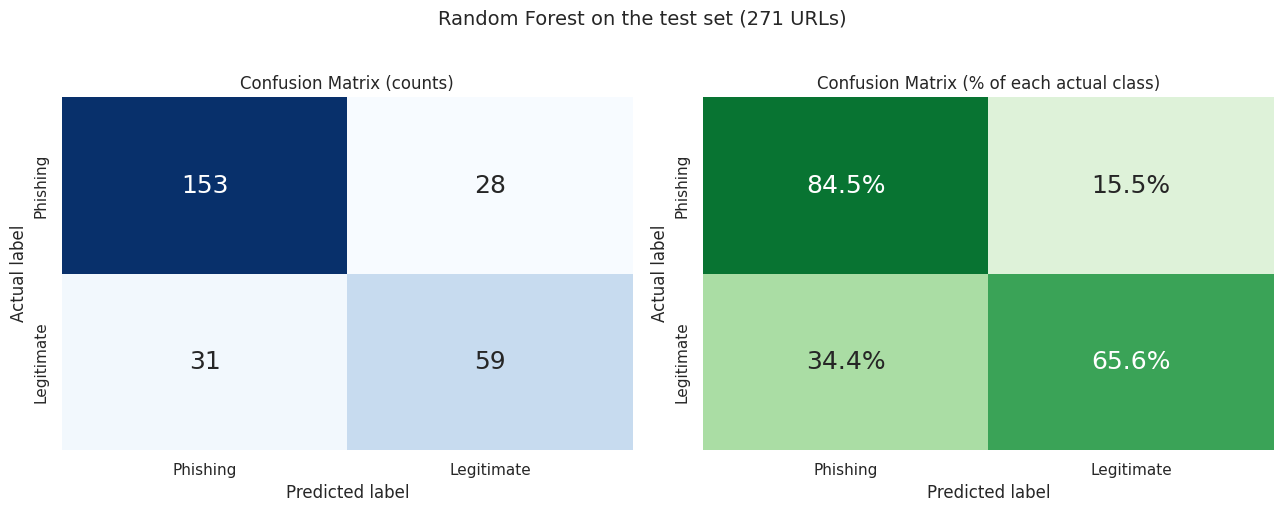

Of 181 real phishing URLs: 153 caught (84.5%), 28 missed (15.5%).
Of 90 real legitimate URLs: 59 passed (65.6%), 31 wrongly flagged (34.4%).


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])        # rows = actual, columns = predicted
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100            # each row as % of that actual class
class_labels = ["Phishing", "Legitimate"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 18},
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("Actual label")

# Right: percentage of each actual class
pct_text = np.array([[f"{v:.1f}%" for v in row] for row in cm_pct])
sns.heatmap(cm_pct, annot=pct_text, fmt="", cmap="Greens", cbar=False, annot_kws={"size": 18},
            vmin=0, vmax=100, xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title("Confusion Matrix (% of each actual class)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")

plt.suptitle(f"{FINAL_MODEL_NAME} on the test set ({len(y_test)} URLs)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Plain-English reading, computed from the matrix (not typed in)
print(f"Of {cm[0].sum()} real phishing URLs: {cm[0, 0]} caught ({cm_pct[0, 0]:.1f}%), "
      f"{cm[0, 1]} missed ({cm_pct[0, 1]:.1f}%).")
print(f"Of {cm[1].sum()} real legitimate URLs: {cm[1, 1]} passed ({cm_pct[1, 1]:.1f}%), "
      f"{cm[1, 0]} wrongly flagged ({cm_pct[1, 0]:.1f}%).")

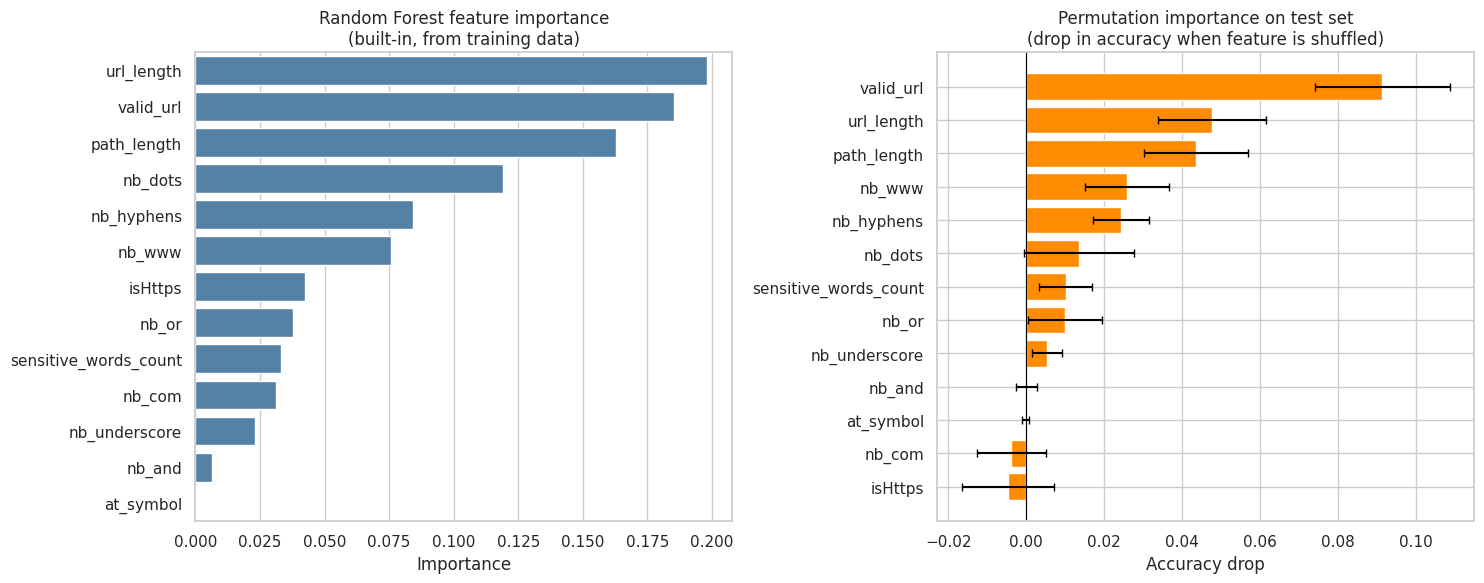

Built-in importance table:


,feature,importance_pct
0,url_length,19.80
1,valid_url,18.55
2,path_length,16.30
3,nb_dots,11.92
4,nb_hyphens,8.42
5,nb_www,7.55
6,isHttps,4.26
7,nb_or,3.77
8,sensitive_words_count,3.31
9,nb_com,3.13


Permutation importance table:


,feature,accuracy_drop,std
0,valid_url,0.0913,0.0173
1,url_length,0.0476,0.0138
2,path_length,0.0435,0.0134
3,nb_www,0.0258,0.0107
4,nb_hyphens,0.0244,0.0072
5,nb_dots,0.0135,0.0141
6,sensitive_words_count,0.0101,0.0068
7,nb_or,0.0100,0.0096
8,nb_underscore,0.0054,0.0038
9,nb_and,-0.0000,0.0026


Top 3 by built-in importance : ['url_length', 'valid_url', 'path_length']
Top 3 by permutation         : ['valid_url', 'url_length', 'path_length']


In [13]:
from sklearn.inspection import permutation_importance

# ---------- Method 1: Random Forest's built-in importance (learned from training data) ----------
imp_df = (pd.DataFrame({"feature": FEATURES, "importance": final_model.feature_importances_})
          .sort_values("importance", ascending=False).reset_index(drop=True))
imp_df["importance_pct"] = (imp_df["importance"] * 100).round(2)

# ---------- Method 2: Permutation importance on the TEST set ----------
# Shuffle one feature at a time and measure how much test accuracy drops.
perm = permutation_importance(final_model, X_test, y_test, n_repeats=20,
                              random_state=RANDOM_STATE, scoring="accuracy", n_jobs=-1)
perm_df = (pd.DataFrame({"feature": FEATURES,
                         "accuracy_drop": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("accuracy_drop", ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=imp_df, y="feature", x="importance", color="steelblue", ax=axes[0])
axes[0].set_title("Random Forest feature importance\n(built-in, from training data)")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")

axes[1].barh(perm_df["feature"][::-1], perm_df["accuracy_drop"][::-1],
             xerr=perm_df["std"][::-1], color="darkorange", ecolor="black", capsize=3)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Permutation importance on test set\n(drop in accuracy when feature is shuffled)")
axes[1].set_xlabel("Accuracy drop")

plt.tight_layout()
plt.show()

print("Built-in importance table:")
display(imp_df[["feature", "importance_pct"]])
print("Permutation importance table:")
display(perm_df.round(4))
print("Top 3 by built-in importance :", imp_df["feature"].head(3).tolist())
print("Top 3 by permutation         :", perm_df["feature"].head(3).tolist())

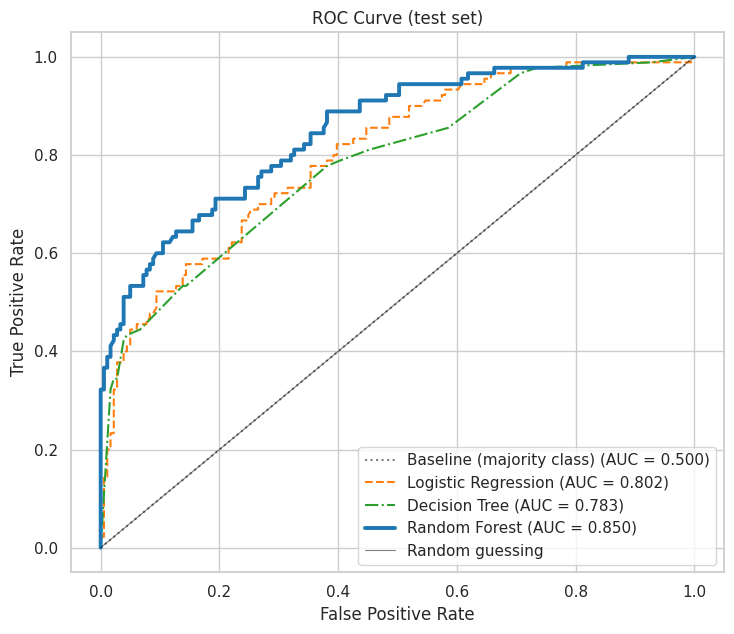

Random Forest ROC-AUC on the test set: 0.8500


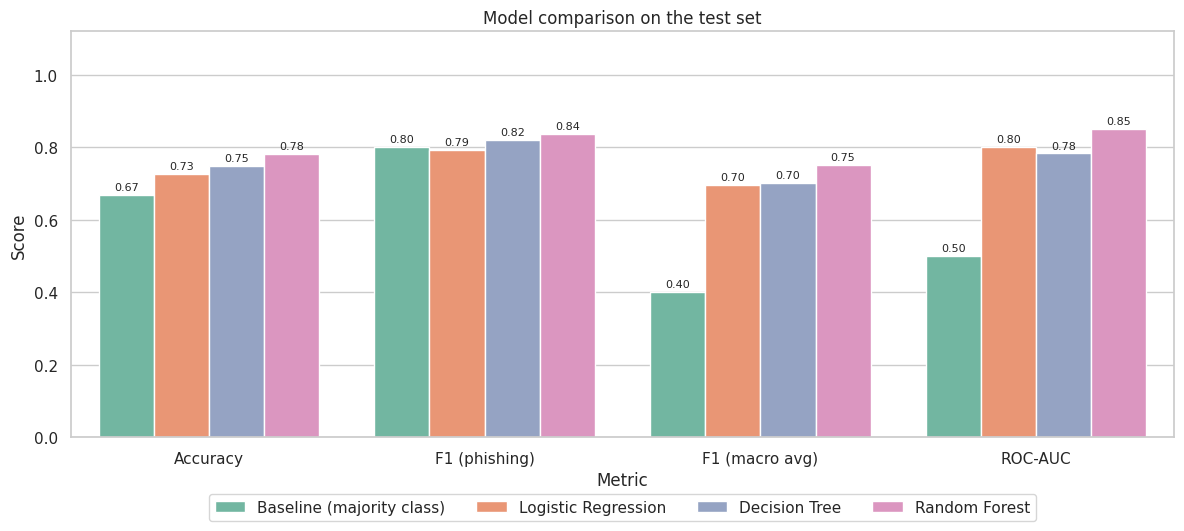

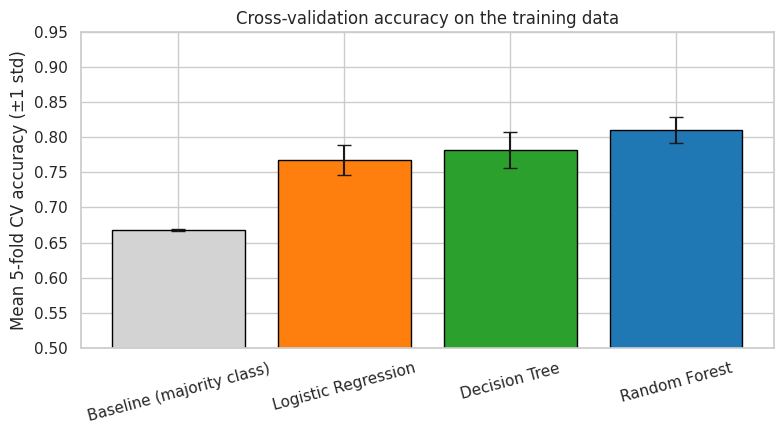

In [14]:
# ---------- ROC curves ----------
# The curve uses the predicted probability of class 1 (Legitimate).
# AUC is the same number whichever class you call "positive".
plt.figure(figsize=(7.5, 6.5))

line_styles = {
    "Baseline (majority class)": dict(color="gray", linestyle=":"),
    "Logistic Regression":       dict(color="tab:orange", linestyle="--"),
    "Decision Tree":             dict(color="tab:green", linestyle="-."),
    "Random Forest":             dict(color="tab:blue", linestyle="-", linewidth=2.8),
}

for name, (_, prob) in predictions.items():
    fpr, tpr, thr = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.3f})", **line_styles[name])

plt.plot([0, 1], [0, 1], color="black", linewidth=0.8, alpha=0.5, label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (test set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

rf_auc = roc_auc_score(y_test, y_proba)
print(f"Random Forest ROC-AUC on the test set: {rf_auc:.4f}")

# ---------- Model comparison bar chart ----------
plot_metrics = ["Accuracy", "F1 (phishing)", "F1 (macro avg)", "ROC-AUC"]
plot_df = comparison[plot_metrics].reset_index().melt(
    id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 5.5))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.ylim(0, 1.12)
plt.title("Model comparison on the test set")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.tight_layout()
plt.show()

# ---------- Cross-validation comparison (more stable than a 271-row test set) ----------
cv_plot = cv_results.reset_index()
plt.figure(figsize=(8, 4.5))
plt.bar(cv_plot["Model"], cv_plot["CV accuracy (mean)"], yerr=cv_plot["CV accuracy (std)"],
        capsize=5, color=["lightgray", "tab:orange", "tab:green", "tab:blue"], edgecolor="black")
plt.ylim(0.5, 0.95)
plt.ylabel("Mean 5-fold CV accuracy (±1 std)")
plt.title("Cross-validation accuracy on the training data")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [22]:
import json, os, datetime

# =====================================================================
# PART 7: Overfitting check (training vs testing accuracy)
# =====================================================================
fit_rows = []
for name, m in models.items():
    fit_rows.append({
        "Model": name,
        "Train accuracy": accuracy_score(y_train, m.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, m.predict(X_test)),
    })
fit_df = pd.DataFrame(fit_rows).set_index("Model")
fit_df["Gap (train - test)"] = fit_df["Train accuracy"] - fit_df["Test accuracy"]
print("OVERFITTING CHECK")
display(fit_df.round(4))

train_acc = float(fit_df.loc[FINAL_MODEL_NAME, "Train accuracy"])
test_acc = float(fit_df.loc[FINAL_MODEL_NAME, "Test accuracy"])
cv_acc_rf = float(cv_results.loc[FINAL_MODEL_NAME, "CV accuracy (mean)"])
print(f"\n{FINAL_MODEL_NAME}: train = {train_acc:.4f} | cross-validation = {cv_acc_rf:.4f} | test = {test_acc:.4f}")
print(f"Train-test gap: {(train_acc - test_acc) * 100:.1f} percentage points")
print("Reading: a train score far above the validation/test scores means the model memorised")
print("some training rows. Cross-validation and test scores close to each other mean the")
print("test result is a fair estimate of future performance.")

# =====================================================================
# Collect everything the Streamlit app needs
# =====================================================================
SAVE_DIR = "model_files"
os.makedirs(SAVE_DIR, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba)          # class 1 (Legitimate) is the positive class here
cm_final = confusion_matrix(y_test, y_pred, labels=[0, 1])

config = {
    "project": "Phishing URL Detector",
    "trained_at": datetime.datetime.now().isoformat(timespec="seconds"),
    "dataset_file": DATASET_FILENAME,
    "final_model": FINAL_MODEL_NAME,
    "sklearn_version": sklearn.__version__,
    "feature_names": FEATURES,                       # exact column order the model expects
    "binary_features": ["valid_url", "isHttps"],
    "target_mapping": {"0": "Phishing URL", "1": "Legitimate URL"},
    "feature_ranges_in_training_data": {
        f: {"min": float(X[f].min()), "max": float(X[f].max())} for f in FEATURES
    },
    "feature_medians_by_class": {
        "phishing": X[y == 0].median().to_dict(),
        "legitimate": X[y == 1].median().to_dict(),
    },
    "data_summary": {
        "raw_rows": int(len(df_raw)),
        "rows_after_cleaning": int(len(df)),
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
        "class_counts_after_cleaning": {"phishing": int((y == 0).sum()), "legitimate": int((y == 1).sum())},
    },
    "metrics_test_set": {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "majority_class_baseline_accuracy": float(y_test.value_counts(normalize=True).max()),
        "precision_phishing": float(precision_score(y_test, y_pred, pos_label=0)),
        "recall_phishing": float(recall_score(y_test, y_pred, pos_label=0)),
        "f1_phishing": float(f1_score(y_test, y_pred, pos_label=0)),
        "precision_legitimate": float(precision_score(y_test, y_pred, pos_label=1)),
        "recall_legitimate": float(recall_score(y_test, y_pred, pos_label=1)),
        "f1_legitimate": float(f1_score(y_test, y_pred, pos_label=1)),
        "f1_macro": float(f1_score(y_test, y_pred, average="macro")),
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
        "confusion_matrix_[phishing,legitimate]": cm_final.tolist(),
    },
    "overfitting_check": {"train_accuracy": train_acc, "cv_accuracy": cv_acc_rf, "test_accuracy": test_acc},
    "model_comparison_test": comparison.reset_index().to_dict(orient="records"),
    "cross_validation": cv_results.reset_index().to_dict(orient="records"),
    "roc_curve": {"fpr": [round(float(v), 4) for v in fpr], "tpr": [round(float(v), 4) for v in tpr]},
    "note": "No scaler/encoder is needed: Random Forest was trained on raw numeric features.",
}

def to_json_safe(o):
    return o.item() if hasattr(o, "item") else str(o)

# =====================================================================
# Save the files
# =====================================================================
joblib.dump(final_model, f"{SAVE_DIR}/phishing_model.pkl", compress=3)
joblib.dump(FEATURES, f"{SAVE_DIR}/feature_names.pkl")
with open(f"{SAVE_DIR}/model_config.json", "w") as f:
    json.dump(config, f, indent=2, default=to_json_safe)
imp_df.to_csv(f"{SAVE_DIR}/feature_importance.csv", index=False)
perm_df.to_csv(f"{SAVE_DIR}/permutation_importance.csv", index=False)

print("\nSaved files:")
for fname in sorted(os.listdir(SAVE_DIR)):
    print(f"  {fname:<28} {os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024:8.1f} KB")

# =====================================================================
# Verify: reload from disk and confirm identical behaviour
# =====================================================================
loaded_model = joblib.load(f"{SAVE_DIR}/phishing_model.pkl")
loaded_features = joblib.load(f"{SAVE_DIR}/feature_names.pkl")

same_features = loaded_features == FEATURES
same_pred = np.array_equal(loaded_model.predict(X_test[loaded_features]), final_model.predict(X_test))
same_proba = np.allclose(loaded_model.predict_proba(X_test[loaded_features]),
                         final_model.predict_proba(X_test))
print("\nVERIFICATION AFTER RELOADING FROM DISK")
print("Feature names/order identical :", same_features)
print("Predictions identical         :", same_pred)
print("Probabilities identical       :", same_proba)

demo = loaded_model.predict_proba(pd.DataFrame([custom], columns=loaded_features))[0]
print(f"Reloaded model on the hand-made example -> phishing probability: "
      f"{demo[list(loaded_model.classes_).index(0)] * 100:.1f}%")

OVERFITTING CHECK


,Train accuracy,Test accuracy,Gap (train - test)
Model,,,
Baseline (majority class),0.6685,0.6679,0.0006
Logistic Regression,0.7729,0.7269,0.0459
Decision Tree,0.8246,0.7491,0.0755
Random Forest,0.9317,0.7823,0.1494



Random Forest: train = 0.9317 | cross-validation = 0.8107 | test = 0.7823
Train-test gap: 14.9 percentage points
Reading: a train score far above the validation/test scores means the model memorised
some training rows. Cross-validation and test scores close to each other mean the
test result is a fair estimate of future performance.

Saved files:
  feature_importance.csv            0.5 KB
  feature_names.pkl                 0.2 KB
  model_config.json                 7.1 KB
  permutation_importance.csv        0.7 KB
  phishing_model.pkl             1800.9 KB

VERIFICATION AFTER RELOADING FROM DISK
Feature names/order identical : True
Predictions identical         : True
Probabilities identical       : True
Reloaded model on the hand-made example -> phishing probability: 53.6%


In [23]:
import shutil

# Bundle everything into one zip file (downloads more reliably than several separate files)
archive_path = shutil.make_archive("phishing_model_files", "zip", SAVE_DIR)

print("Zip created:", archive_path)
print(f"Zip size   : {os.path.getsize(archive_path) / 1024:.1f} KB")
print("\nFiles inside the zip:")
for fname in sorted(os.listdir(SAVE_DIR)):
    print("  -", fname)

print("\nYour Colab scikit-learn version :", sklearn.__version__)
print("Install the SAME version locally:  pip install scikit-learn==" + sklearn.__version__)

try:
    from google.colab import files
    files.download(archive_path)          # triggers the browser download
    print("\nDownload started. If nothing happens, allow pop-ups/downloads for colab.research.google.com,")
    print("or use the Files panel (folder icon on the left) -> right-click 'phishing_model_files.zip' -> Download.")
except ImportError:
    print("\nNot running in Colab. The zip is in the current folder:", archive_path)

Zip created: /content/phishing_model_files.zip
Zip size   : 1784.7 KB

Files inside the zip:
  - feature_importance.csv
  - feature_names.pkl
  - model_config.json
  - permutation_importance.csv
  - phishing_model.pkl

Your Colab scikit-learn version : 1.6.1
Install the SAME version locally:  pip install scikit-learn==1.6.1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started. If nothing happens, allow pop-ups/downloads for colab.research.google.com,
or use the Files panel (folder icon on the left) -> right-click 'phishing_model_files.zip' -> Download.
